In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.mode.copy_on_write = True

C:\Users\cdrSp\AppData\Local\Temp\ipykernel_2004\3089171456.py:11: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

### Setting up dataset

In [3]:
water_pollution = pd.read_csv('../final_project/water_pollution_disease.csv')
water_pollution

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,19.86,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


### Variables

In [14]:
variables = water_pollution[["Country","Region","Year","Water Source Type","Contaminant Level (ppm)","pH Level","Turbidity (NTU)","Dissolved Oxygen (mg/L)","Nitrate Level (mg/L)","Lead Concentration (µg/L)","Bacteria Count (CFU/mL)","Water Treatment Method","Access to Clean Water (% of Population)","Infant Mortality Rate (per 1,000 live births)","GDP per Capita (USD)","Healthcare Access Index (0-100)","Urbanization Rate (%)","Sanitation Coverage (% of Population)","Rainfall (mm per year)","Temperature (°C)","Population Density (people per km²)", "Diarrheal Cases per 100,000 people"]]

df = pd.DataFrame(variables)

df_encoded = pd.get_dummies(df, columns=["Country", "Region", "Water Source Type", "Water Treatment Method"], drop_first=True, dtype=float)

print("Encoded DataFrame:")
print(df_encoded)

Encoded DataFrame:
      Year  Contaminant Level (ppm)  pH Level  Turbidity (NTU)  \
0     2015                     6.06      7.12             3.93   
1     2017                     5.24      7.84             4.79   
2     2022                     0.24      6.43             0.79   
3     2016                     7.91      6.71             1.96   
4     2005                     0.12      8.16             4.22   
...    ...                      ...       ...              ...   
2995  2002                     2.82      7.40             4.43   
2996  2019                     8.13      8.33             4.77   
2997  2009                     1.18      6.76             4.75   
2998  2009                     7.56      6.12             3.49   
2999  2013                     0.98      7.69             2.55   

      Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
0                        4.28                  8.28   
1                        3.86                 15.74   
2                      

In [15]:
X = df_encoded.drop("Diarrheal Cases per 100,000 people", axis=1)
y = df_encoded["Diarrheal Cases per 100,000 people"]

#Adding an intercept
X = sm.add_constant(X)

X

,const,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),...,Region_North,Region_South,Region_West,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Chlorination,Water Treatment Method_Filtration
0,1.0,2015,6.06,7.12,3.93,4.28,8.28,7.89,3344,33.60,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,2017,5.24,7.84,4.79,3.86,15.74,14.68,2122,89.54,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,2022,0.24,6.43,0.79,3.42,36.67,9.96,2330,35.29,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2016,7.91,6.71,1.96,3.12,36.92,6.77,3779,57.53,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,2005,0.12,8.16,4.22,9.15,49.35,12.51,4182,36.60,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1.0,2002,2.82,7.40,4.43,9.69,37.58,18.52,359,36.34,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2996,1.0,2019,8.13,8.33,4.77,7.62,38.05,16.98,3810,81.72,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2997,1.0,2009,1.18,6.76,4.75,7.07,36.13,7.99,1440,80.11,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2998,1.0,2009,7.56,6.12,3.49,8.93,25.30,19.86,2919,78.26,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Training and Test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=314,
                                                    test_size=0.25,
                                                    shuffle=True) 
Train = pd.concat([X_train, y_train], axis=1)
Test = pd.concat([X_test, y_test], axis=1)

### Polynomial Regression

In [43]:
X_single = df[['Nitrate Level (mg/L)']]

In [44]:
poly = PolynomialFeatures(degree=3)

In [45]:
X_poly = poly.fit_transform(X_single)

In [46]:
linreg = LinearRegression()
linreg.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
X_sorted = np.sort(X_single.values, axis=0)
X_sorted_poly = poly.transform(X_sorted)

c:\Users\cdrSp\anaconda3\envs\islp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [50]:
y_pred = linreg.predict(X_sorted_poly)

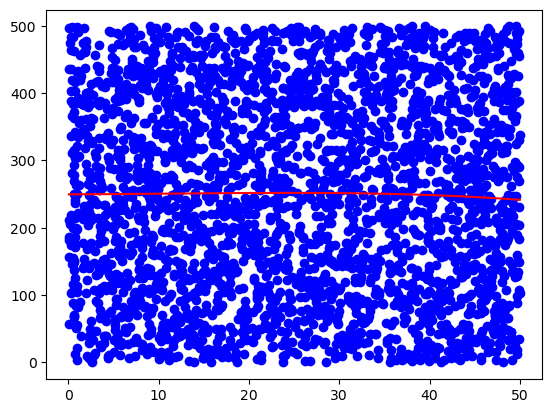

In [51]:
plt.scatter(X_single, y, color='blue')
plt.plot(X_sorted, y_pred, color='red')